In [1]:
import bottleneck as bn
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scienceplots
import scipy
import scipy.signal
import scipy.special
import scipy.stats
import sklearn.decomposition
import astropy.io
import datetime
import astropy.time
import pandas as pd
from scipy.signal import butter, filtfilt
import pywt
import ssqueezepy
import matplotlib.dates as mdate

import scipy.ndimage
import ssqueezepy
import numpy as np


from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])
cmap = 'jet'


figsize_short = (8, 4)
figsize_normal = (8, 6)
figsize_tall = (8, 8)
plt.rcParams['figure.figsize'] = figsize_short
plt.rcParams['axes.labelpad'] = 6.0
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'none'


title_font = {'fontsize': 16, 'weight': 'bold', 'style': 'italic'}
path_effect = [pe.withStroke(linewidth=2.0, foreground="k")]

read_path = 'docs/Data/'
save_path = 'docs/Figure/'

perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
matlab_perula = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_perula', np.array(perula_df))

jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')
matlab_jet = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_jet', np.array(jet_df))

%matplotlib ipympl

In [ ]:
# Using pandas
t_pd = pd.Timestamp('2000-01-01T00:00:00')

# Using astropy
t_astropy = astropy.time.Time('2000-01-01T00:00:00')

# Using datetime
t_datetime = datetime.datetime(2000, 1, 1, 0, 0)

# Using numpy
t_np = np.datetime64('2000-01-01T00:00:00')

# np.datetime64 to Unix timestamp
t_np.astype(float)
# np.float64(946684800.0)

np.float64(946684800.0)

In [44]:
# Convert np.datetime64 to pd.Timestamp
t_np = np.datetime64('2023-01-01T12:00:00')
t_pd = pd.Timestamp(t_np)
print("np.datetime64 to pd.Timestamp:", t_pd)

# Convert pd.Timestamp to datetime.datetime
t_datetime = t_pd.to_pydatetime()
print("pd.Timestamp to datetime.datetime:", t_datetime)

# Convert datetime.datetime to astropy.time.Time
t_astropy = astropy.time.Time(t_datetime)
# Convert an array of datetime.datetime to astropy.time.Time
datetime_array = [datetime.datetime(2023, 1, 1, 12, 0), datetime.datetime(2023, 1, 2, 12, 0)]
t_astropy_array = astropy.time.Time(datetime_array)
print("Array of datetime.datetime to astropy.time.Time:", t_astropy_array)
print("datetime.datetime to astropy.time.Time:", t_astropy)

# Convert astropy.time.Time to np.datetime64
t_np_from_astropy = np.datetime64(t_astropy.to_datetime())
print("astropy.time.Time to np.datetime64:", t_np_from_astropy)

# Convert astropy.time.Time to pd.Timestamp
t_pd_from_astropy = pd.Timestamp(t_astropy.to_datetime())
print("astropy.time.Time to pd.Timestamp:", t_pd_from_astropy)

# Convert datetime.datetime to np.datetime64
t_np_from_datetime = np.datetime64(t_datetime)
print("datetime.datetime to np.datetime64:", t_np_from_datetime)

# Convert np.datetime64 to datetime.datetime
t_datetime_from_np = pd.Timestamp(t_np).to_pydatetime()
print("np.datetime64 to datetime.datetime:", t_datetime_from_np)
# Generate numpy.datetime64 array using year_array, month_array, and day_array
year = np.array([2023, 2023, 2023])
month = np.array([1, 2, 3])
day = np.array([1, 2, 3])
t_array = np.array([np.datetime64(f"{y:04d}-{m:02d}-{d:02d}") for y, m, d in zip(year, month, day)])

# Generate numpy.datetime64 array using year_array and doy_array (day of year)
year = 2023
doy = np.array([1, 32, 60])  # Day of year for Jan 1, Feb 1, Mar 1 in a non-leap year
# t_array = np.array([np.datetime64(f"{y:04d}-01-01") + np.timedelta64(d - 1, 'D') for y, d in zip(year, doy)])
t_array = np.datetime64(f"{year:04d}-01-01") + (doy - 1).astype('timedelta64[D]')

# Convert datetime_array to numpy.datetime64 array
datetime_array_to_np = np.array([np.datetime64(dt) for dt in datetime_array])
print("datetime_array to numpy.datetime64 array:", datetime_array_to_np)

# Convert datetime_array to pandas.Timestamp array
datetime_array_to_pd = [pd.Timestamp(dt) for dt in datetime_array]
print("datetime_array to pandas.Timestamp array:", datetime_array_to_pd)

# Convert datetime_array to astropy.time.Time
datetime_array_to_astropy = astropy.time.Time(datetime_array)
print("datetime_array to astropy.time.Time:", datetime_array_to_astropy)

np.datetime64 to pd.Timestamp: 2023-01-01 12:00:00
pd.Timestamp to datetime.datetime: 2023-01-01 12:00:00
Array of datetime.datetime to astropy.time.Time: [datetime.datetime(2023, 1, 1, 12, 0) datetime.datetime(2023, 1, 2, 12, 0)]
datetime.datetime to astropy.time.Time: 2023-01-01 12:00:00
astropy.time.Time to np.datetime64: 2023-01-01T12:00:00.000000
astropy.time.Time to pd.Timestamp: 2023-01-01 12:00:00
datetime.datetime to np.datetime64: 2023-01-01T12:00:00.000000
np.datetime64 to datetime.datetime: 2023-01-01 12:00:00
datetime_array to numpy.datetime64 array: ['2023-01-01T12:00:00.000000' '2023-01-02T12:00:00.000000']
datetime_array to pandas.Timestamp array: [Timestamp('2023-01-01 12:00:00'), Timestamp('2023-01-02 12:00:00')]
datetime_array to astropy.time.Time: [datetime.datetime(2023, 1, 1, 12, 0) datetime.datetime(2023, 1, 2, 12, 0)]


In [36]:
t0, t1, t2 = astropy.time.Time('1972-06-30T23:59:59'), astropy.time.Time('1972-06-30T23:59:60'), astropy.time.Time('1972-07-01T00:00:00')
# t0.to_value('unix').astype('datetime64[s]'), t1.to_value('unix').astype('datetime64[s]'), t2.to_value('unix').astype('datetime64[s]')
t0.utc.to_value('unix').astype('datetime64[s]'), t1.utc.to_value('unix').astype('datetime64[s]'), t2.utc.to_value('unix').astype('datetime64[s]')

(np.datetime64('1972-06-30T23:59:58'),
 np.datetime64('1972-06-30T23:59:59'),
 np.datetime64('1972-07-01T00:00:00'))

In [ ]:
t_np = np.datetime64('2000-01-01T00:00:00')
t_np_ms = t_np.astype('datetime64[ms]') # np.datetime64('2000-01-01T00:00:00.000')
t_np_ns = t_np.astype('datetime64[ns]') # np.datetime64('2000-01-01T00:00:00.000000000')

t_np.astype(float) # np.float64(946684800.0)
t_np.astype('datetime64[ns]').astype(float) # np.float64(9.466848e+17)

np.float64(9.466848e+17)

In [42]:
np.arange(10).astype('timedelta64[s]')

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='timedelta64[s]')

In [ ]:
omega0 = 2 * np.pi * 6.0

N = 2 ** 10
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt  # Sampling frequency

sig_sin = np.sin(omega0 * t)
sig_cos = np.cos(omega0 * t)

# f0: Frequency at t = 0
# f1: Frequency at t = t1
sig_chrip = scipy.signal.chirp(t, f0 = omega0 / 2 / np.pi, t1 = 1, f1 = omega0 / 2 / np.pi * 3)

# fc: central frequency
# bw: bandwidth
sig_gauss_pulse = scipy.signal.gausspulse((t - np.mean(t)), fc = omega0 / 1 / np.pi, bw = 0.5)

sig_square = scipy.signal.square(omega0 * t)

sig_sawtooth = scipy.signal.sawtooth(omega0 * t)

# idx : None or int or tuple of int or 'mid', optional
sig_unit_impulse = scipy.signal.unit_impulse(t.size, idx = 'mid')

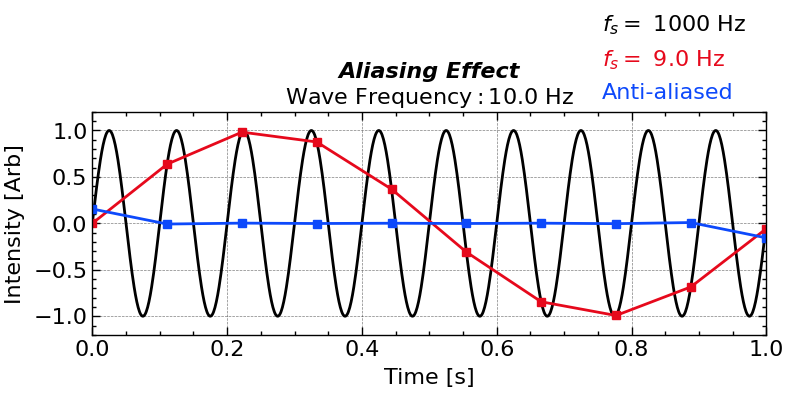

In [18]:
plt.close()
ax1 = plt.subplot(1, 1, 1)


omega0 = 2 * np.pi * 10.0
N = 1000
N_DOWNSAMPLE = 111
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(omega0 * t) + np.random.randn(t.size) * 0.0
# ax1.plot(time, signal, 'k-', label = 'Signal')
ax1.plot(t, sig, 'k-', label=r'$\mathit{f_s}=$' + ' %d Hz' % fs)
ax1.plot(t[::N_DOWNSAMPLE], sig[::N_DOWNSAMPLE], 'C1-', label='$f_s=$ %.1f Hz' % (fs / N_DOWNSAMPLE), markersize=6, fillstyle = 'full')
ax1.plot(t[::N_DOWNSAMPLE], sig[::N_DOWNSAMPLE], 'C1s', markersize=6, fillstyle = 'full')

ax1.plot(t[::N_DOWNSAMPLE], scipy.signal.decimate(sig, N_DOWNSAMPLE, ftype='fir', zero_phase=True), 'C0-', label='Anti-aliased')
ax1.plot(t[::N_DOWNSAMPLE], scipy.signal.decimate(sig, N_DOWNSAMPLE, ftype='fir', zero_phase=True), 'C0s', markersize=6, fillstyle = 'full')

# plt.title('Signal')
plt.xlabel('Time [s]')
plt.ylabel('Intensity [Arb]')

ax1.set_xlim(0, 1)
ax1.set_ylim(-1.2, 1.2)

# ax1.legend(loc='upper center', frameon=False, ncol = 3, bbox_to_anchor=(0.5, 1.18))
# ax1.set_title('Aliasing', y = 1.13, **title_font)

ax1.legend(loc='lower right', frameon=False, ncol = 1, bbox_to_anchor=(1., 0.95), labelcolor="linecolor", handlelength = 0, handletextpad = 0, )
ax1.set_title('Aliasing Effect\n' + r'$\mathrm{Wave\ Frequency: %.1f\ Hz}$' % (omega0 / 2 / np.pi),  **title_font)

plt.tight_layout()

plt.savefig(save_path + 'figure_aliasing' + '.png',bbox_inches='tight',dpi=300)

plt.show()

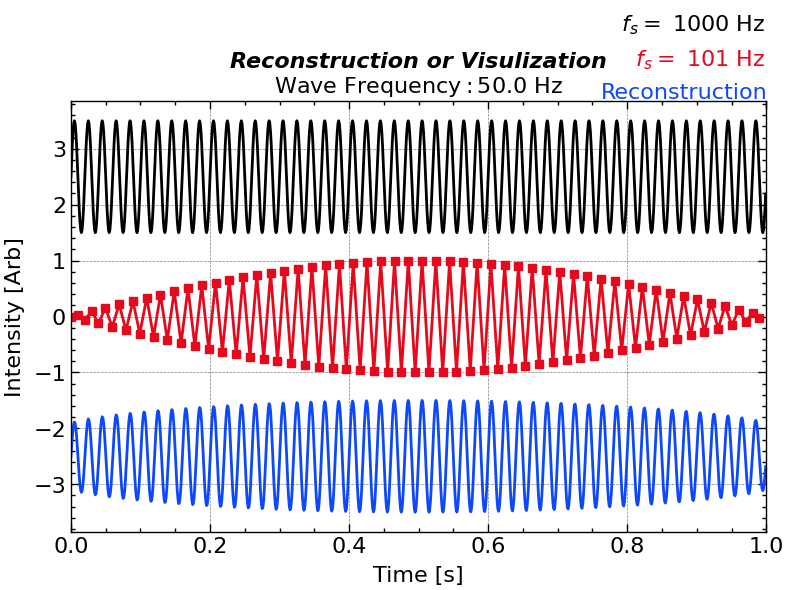

In [101]:
plt.close()
plt.figure(figsize = figsize_normal)
ax1 = plt.subplot(1, 1, 1)


N = 1000
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt


sig = np.sin(omega0 * t)
ax1.plot(t, 2.5 + sig, 'k-', label=r'   $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 0)


N = 101
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt

omega0 = 2 * np.pi * fs / 2.02

sig = np.sin(omega0 * t) + np.random.randn(t.size) * 0.0
# ax1.plot(time, signal, 'k-', label = 'Signal')
ax1.plot(t, sig, 'C1-', label=r'     $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 1, alpha = 1.0)
ax1.plot(t, sig, 'C1s', zorder = 1, markersize=6, fillstyle = 'full')

N = 1000
t_interp = np.linspace(0, 1, N, endpoint=False)

def sinc_interp(t_interp):
    weight = np.sinc((t_interp[:, None] - t[None, :]) / dt)
    return weight @ sig

ax1.plot(t_interp, -2.5 + sinc_interp(t_interp), 'C0-', label='Reconstruction', zorder = 2)


# plt.title('Signal')
plt.xlabel('Time [s]')
plt.ylabel('Intensity [Arb]')

ax1.set_xlim(0, 1)
# ax1.set_ylim(-1.2, 1.2)

ax1.legend(loc='lower right', frameon=False, ncol = 1, bbox_to_anchor=(1.03, .95), labelcolor="linecolor", handlelength = 0, handletextpad = 0)
ax1.set_title('Reconstruction or Visulization\n' + r'$\mathrm{Wave\ Frequency: %.1f\ Hz}$' % (omega0 / 2 / np.pi),  **title_font)

plt.tight_layout()

plt.savefig(save_path + 'figure_nyquist_reconstruction' + '.png',bbox_inches='tight',dpi=300)

plt.show()

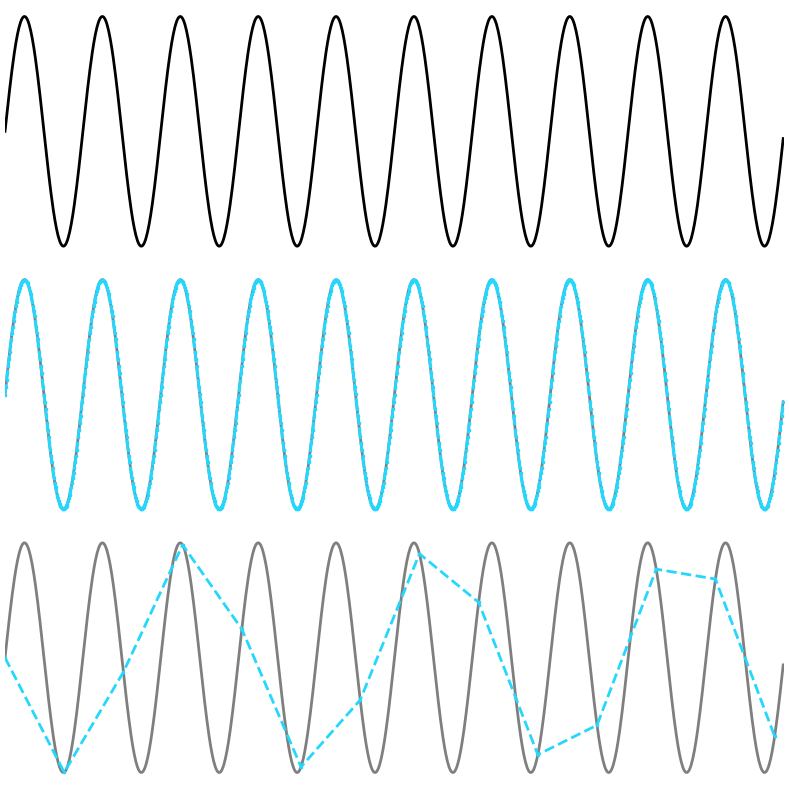

In [167]:
plt.close()
plt.figure(figsize = figsize_tall)

ax1 = plt.subplot(3, 1, 1)
ax2 = plt.subplot(3, 1, 2, sharex = ax1)
ax3 = plt.subplot(3, 1, 3, sharex = ax1)

omega0 = 2 * np.pi * 10
N = 1000
t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt


sig = np.sin(omega0 * t)
ax1.plot(t, sig, 'k-', label=r'   $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 0, lw = 2)
ax2.plot(t, sig, 'k-', label=r'   $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 0, lw = 2, alpha = 0.5)
ax3.plot(t, sig, 'k-', label=r'   $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 0, lw = 2, alpha = 0.5)
ax2.plot(t, sig, 'C5s--', label=r'   $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 0, markersize = 2)

N_DOWNSAMPLE = 76
ax3.plot(t[::N_DOWNSAMPLE], sig[::N_DOWNSAMPLE], 'C5s--', label=r'   $\mathit{f_s}=$' + ' %d Hz' % fs, zorder = 0, markersize = 2)

plt.xlabel('Time [s]')
plt.ylabel('Intensity [Arb]')

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 1)
    ax.axis('off')
plt.tight_layout()
plt.show()

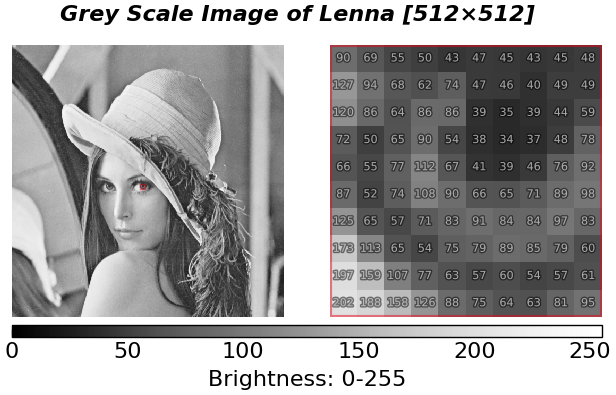

In [114]:
plt.close()
plt.subplots_adjust(wspace = 0.05, bottom = 0.2)
ax1 = plt.subplot(1, 2, 1, aspect = 'equal')
ax2 = plt.subplot(1, 2, 2, aspect = 'equal')

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

leena_img = plt.imread(read_path + 'leena.png')
leena_img_gray = rgb2gray(leena_img)[::-1, ::-1] * 255
pc1 = ax1.pcolormesh(leena_img_gray, cmap = 'Greys_r', vmax = 255, vmin = 0)
ax2.pcolormesh(leena_img_gray, cmap = 'Greys_r', vmax = 255, vmin = 0)

cbar_ax1 = plt.gcf().add_axes([ax1.get_position().x0, ax1.get_position().y0 - 0.05, ax2.get_position().x1 - ax1.get_position().x0, 0.03])
cbar1 = plt.colorbar(pc1, cax = cbar_ax1, orientation = 'horizontal', label = 'Brightness: 0-255')

x_start_idx=  240
x_end_idx = 250

y_start_idx=  240
y_end_idx = 250

ax1.add_patch(Rectangle((x_start_idx, y_start_idx), x_end_idx - x_start_idx, y_end_idx - y_start_idx, linewidth=1, edgecolor='C1', facecolor='none', alpha = 0.5))
ax2.add_patch(Rectangle((x_start_idx, y_start_idx), x_end_idx - x_start_idx, y_end_idx - y_start_idx, linewidth=3, edgecolor='C1', facecolor='none', alpha = 0.5))

for x_idx in range(x_start_idx, x_end_idx):
    for y_idx in range(y_start_idx, y_end_idx):
        ax2.text(x_idx + 0.5, y_idx + 0.5, ('%d' % (leena_img_gray)[y_idx, x_idx])[:], color = 'w', alpha = 0.5, fontsize = 8, ha = 'center', va = 'center', path_effects = path_effect)

ax2.set_xlim(x_start_idx, x_end_idx)
ax2.set_ylim(y_start_idx, y_end_idx)

ax1.axis('off')
ax2.axis('off')

plt.suptitle('Grey Scale Image of Lenna [512×512]', **title_font)
# plt.tight_layout()

plt.show()

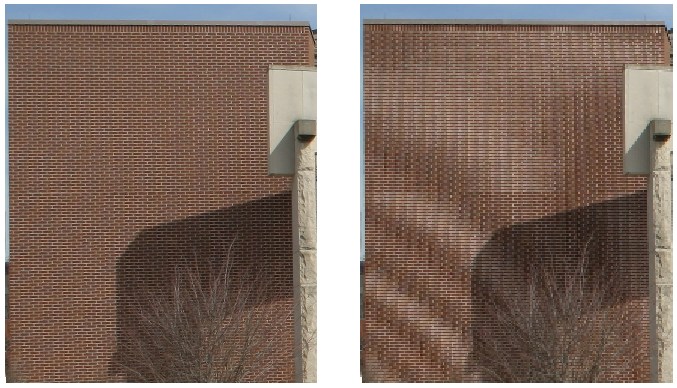

In [182]:
plt.close()
plt.subplots_adjust(wspace = 0.05, bottom = 0.2)
ax1 = plt.subplot(1, 2, 1, aspect = 'equal')
ax2 = plt.subplot(1, 2, 2, aspect = 'equal')

bricks_wall_img = plt.imread(read_path + 'bricks_wall.jpg')
ax1.pcolormesh(bricks_wall_img[::-1, ::-1, :])
ax2.pcolormesh(bricks_wall_img[::-3, ::-3, :])
# ax1.set_title(f'Original [{bricks_wall_img.shape[0]}×{bricks_wall_img.shape[1]}]', **title_font)
# ax2.set_title('Downsampled (3×)', **title_font)
for ax in [ax1, ax2]:
    ax.axis('off')

plt.tight_layout()

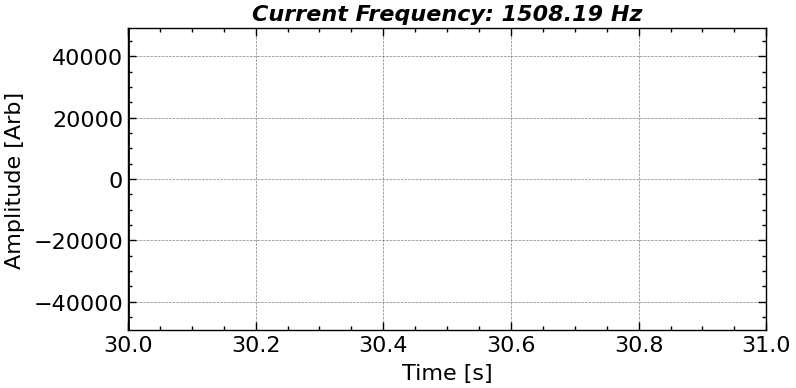

In [11]:
from scipy.io.wavfile import write
import numpy as np

samplerate = 44100; fs = 1 / 3.5

t = np.arange(0., 30., 1 / samplerate)
amplitude = np.iinfo(np.int16).max

phase = 2 * np.pi * (np.exp(fs * t))
sig = amplitude * scipy.signal.square(phase)


write("example.wav", samplerate, sig.astype(np.int16))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from functools import partial
import imageio_ffmpeg

plt.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

fig, ax = plt.subplots()
ax.plot(t, sig)
line1, = ax.plot([], [], 'k-')
title1 = ax.set_title('Current Frequency: %.2f Hz' % fs, **title_font)
def init():
    # ax.set_xlim(0, 2*np.pi)
    # ax.set_ylim(-1, 1)
    ax.set_ylabel('Amplitude [Arb]')
    ax.set_xlabel('Time [s]')
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.5 * amplitude, 1.5 * amplitude)
    plt.tight_layout()
    return line1,

def update(frame, ln):
    ax.set_xlim(np.floor(frame / samplerate), np.floor(frame / samplerate) + 1)
    ln.set_data([frame / samplerate, frame / samplerate], [-1.5 * amplitude, 1.5 * amplitude])
    _f = fs * np.exp(frame / samplerate * fs)
    title1.set_text('Current Frequency: %.2f Hz' % _f)
    return ln,

ani = FuncAnimation(
    fig, partial(update, ln=line1),
    frames=np.linspace(0, samplerate * 30, 30 * 60),
    init_func=init, interval = 1e3 / 60)


ani.save(filename="ffmpeg_example.mp4", writer="ffmpeg", dpi = 300, fps = 60)

plt.show()

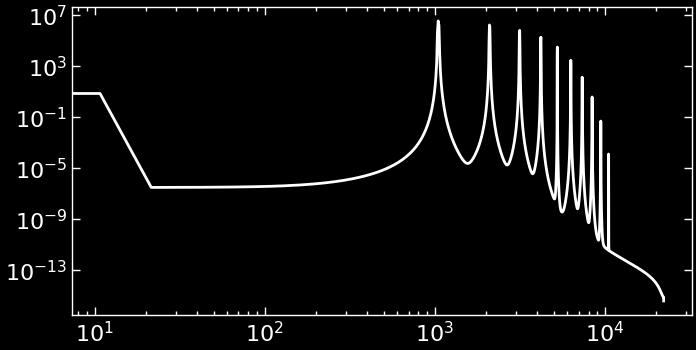

In [ ]:
from scipy.io.wavfile import write
import numpy as np

samplerate = 44100

t = np.arange(0., 5., 1 / samplerate)
amplitude = np.iinfo(np.int16).max

f0 = 261.63 * 2
sig0 = amplitude * (np.cos(2 * np.pi * f0 * t) ** 20)

# sig0 = amplitude * (np.cos(2 * np.pi * f0 * t) ** 1)
sig0 -= sig0.mean()

# f1 = f0 * 1.25
# sig1 = amplitude * np.cos(2 * np.pi * f1 * t) / 2

# f2 = f0 * 1.5
# sig2 = amplitude * np.cos(2 * np.pi * f2 * t) / 4

# sig = sig0 + sig1 + sig2

sig = sig0

write("central_c_no_basic.wav", samplerate, sig.astype(np.int16))


freq, psd = scipy.signal.welch(sig, fs = samplerate, nperseg = 4096)

plt.close()
ax1 = plt.subplot()
ax1.plot(freq, psd, 'w-')

ax1.loglog()

plt.show()